In [1]:
#################################################################
### Compare metrics across all strategies for the given model ###
#################################################################

In [2]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple, Literal

# Allow importing eval.metrics from the scripts/ directory
sys.path.insert(0, str(Path.cwd().parent / "scripts"))
# Available for instance-level analysis:
from eval.metrics import read_traj_metrics

In [3]:
from analysis.dashboards import (
    build_single_report,
    build_comparison_report,
)
from analysis.data_loading import (
    load_metrics,
    load_instance_observations,
    load_instance_observations_by_id,
    load_instance_pass_rates_by_id,
)
from analysis.stat_significance import (
    _STAT_AGENT_FIELDS,
    get_stat_significance_overall_df,
    get_stat_significance_per_instance_df,
    get_per_instance_pass_rate_df,
)
from analysis.cross_eval import build_cross_eval_comparison_df
from analysis.comparison_nway import (
    STRATEGY_STYLES,
    plot_pass_rate_nway,
    plot_pooled_metrics_nway,
    build_resolution_table,
    build_compact_stat_sig_df,
    display_compact_stat_sig,
    build_per_instance_pass_rate_nway,
    display_per_instance_metric_sig_nway,
    build_metrics_summary_df,
    display_metrics_summary,
)

In [4]:
### MODELS ###
GPT_5_4 = "GPT-5.4"
SONNET_4_6 = "Claude Sonnet 4.6"

In [5]:
##########################################################
### SELECT THE MODEL WHICH TO BUILD THE COMPARISON FOR ###
##########################################################

DESIRED_MODEL = GPT_5_4 # GPT_5_4, SONNET_4_6

In [6]:
@dataclass
class Strategy:
    name: str
    display_name: str
    filepath: Path
    model: Literal["GPT-5.4", "Claude Sonnet 4.6"]


def result(relative_filepath: str) -> Path:
    results_filepath_prefix = "/Users/vartiukhov/dev/studies/hse/thesis/thesis-metamorphic-eval/artifacts/results/eval"
    return Path(results_filepath_prefix) / relative_filepath

In [7]:
# GPT-5.4
strategies_gpt: List[Strategy] = [
    Strategy(
        name="s0-original",
        display_name="s0-original",
        filepath=result("s0-original/java_20_gpt5.4_cost_3.0_runs_5"),
        model=GPT_5_4,
    ),
    Strategy(
        name="s1-renaming",
        display_name="s1-renaming",
        # swap to:
        # 2nd: java_20_s1_2nd_gpt5.4_cost_3.0_runs_5
        # 3rd: java_20_s1_3rd_gpt5.4_cost_3.0_runs_5
        filepath=result(
            "s1-renaming/java_20_s1_gpt5.4_cost_3.0_runs_5" # 1st
            # "s1-renaming/java_20_s1_2nd_gpt5.4_cost_3.0_runs_5" # 2nd
            # "s1-renaming/java_20_s1_3rd_gpt5.4_cost_3.0_runs_5" # 3rd
        ),
        model=GPT_5_4,
    ),
    Strategy(
        name="s2-structural",
        display_name="s2-structural",
        filepath=result("s2-structural/java_20_s2_gpt5.4_cost_3.0_runs_5"),
        model=GPT_5_4,
    ),
    Strategy(
        name="s3-problem-statement",
        display_name="s3-problem-statement",
        filepath=result("s3-problem-statement/java_20_s3_gpt5.4_cost_3.0_runs_5"),
        model=GPT_5_4,
    ),
    Strategy(
        name="s4-combined",
        display_name="s4-combined",
        filepath=result("s4-combined/java_20_s4_gpt5.4_cost_3.0_runs_5"),
        model=GPT_5_4,
    ),
]

# Claude Sonnet 4.6
strategies_sonnet: List[Strategy] = [
    Strategy(
        name="s0-original",
        display_name="s0-original",
        filepath=result("s0-original/java_20_sonnet4.6_cost_3.0_runs_5"),
        model=SONNET_4_6,
    ),
    Strategy(
        name="s1-renaming",
        display_name="s1-renaming",
        # swap to:
        # [CHECKED -> SAME] 2nd: s1-renaming/java_20_s1_2nd_sonnet4.6_cost_3.0_runs_5
        filepath=result("s1-renaming/java_20_s1_sonnet4.6_cost_3.0_runs_5"),
        model=SONNET_4_6,
    ),
    Strategy(
        name="s2-structural",
        display_name="s2-structural",
        filepath=result("s2-structural/java_20_s2_sonnet4.6_cost_3.0_runs_5"),
        model=SONNET_4_6,
    ),
    Strategy(
        name="s3-problem-statement",
        display_name="s3-problem-statement",
        filepath=result("s3-problem-statement/java_20_s3_sonnet4.6_cost_3.0_runs_5"),
        model=SONNET_4_6,
    ),
    Strategy(
        name="s4-combined",
        display_name="s4-combined",
        filepath=result("s4-combined/java_20_s4_sonnet4.6_cost_3.0_runs_5"),
        model=SONNET_4_6,
    ),
]

In [8]:
# ── Select model ────────────────────────────────────────────────────────────
# Change this to strategies_sonnet to switch models; then re-run cells below
strategies = None

if DESIRED_MODEL == GPT_5_4:
    strategies = strategies_gpt
elif DESIRED_MODEL == SONNET_4_6:
    strategies = strategies_sonnet
else:
    raise ValueError(
        f"DESIRED_MODEL must be either '{GPT_5_4}' or '{SONNET_4_6}', got '{DESIRED_MODEL}'")

print(f"Active model : {strategies[0].model}")
for s in strategies:
    print(f"  {s.display_name:<25} {s.filepath}")

Active model : GPT-5.4
  s0-original               /Users/vartiukhov/dev/studies/hse/thesis/thesis-metamorphic-eval/artifacts/results/eval/s0-original/java_20_gpt5.4_cost_3.0_runs_5
  s1-renaming               /Users/vartiukhov/dev/studies/hse/thesis/thesis-metamorphic-eval/artifacts/results/eval/s1-renaming/java_20_s1_gpt5.4_cost_3.0_runs_5
  s2-structural             /Users/vartiukhov/dev/studies/hse/thesis/thesis-metamorphic-eval/artifacts/results/eval/s2-structural/java_20_s2_gpt5.4_cost_3.0_runs_5
  s3-problem-statement      /Users/vartiukhov/dev/studies/hse/thesis/thesis-metamorphic-eval/artifacts/results/eval/s3-problem-statement/java_20_s3_gpt5.4_cost_3.0_runs_5
  s4-combined               /Users/vartiukhov/dev/studies/hse/thesis/thesis-metamorphic-eval/artifacts/results/eval/s4-combined/java_20_s4_gpt5.4_cost_3.0_runs_5


In [9]:
# Load metrics + pooled observations for every strategy
all_metrics = {s.name: load_metrics(s.filepath) for s in strategies}
all_obs     = {s.name: load_instance_observations(s.filepath) for s in strategies}

In [10]:
# Load per-instance data for per-project stat sig and pass rate fractions
all_obs_by_id        = {s.name: load_instance_observations_by_id(s.filepath) for s in strategies}
all_pass_rates_by_id = {s.name: load_instance_pass_rates_by_id(s.filepath)  for s in strategies}

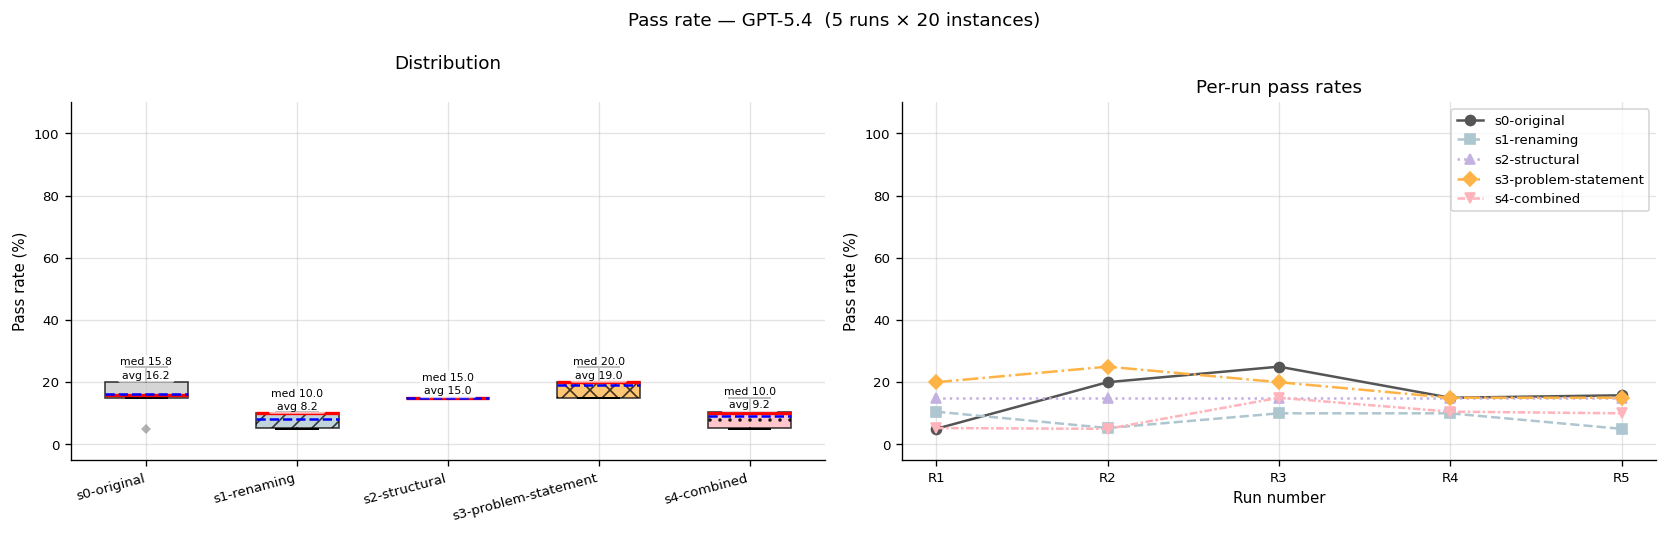

In [11]:
# ── Pass rate comparison ─────────────────────────────────────────────────────
plot_pass_rate_nway(strategies, all_metrics)
plt.show()

Reasoning tokens: y-axis clipped at 30,000. Outliers cut — s0-original: ↑4, s1-renaming: ↑3, s2-structural: ↑4, s3-problem-statement: ↑3, s4-combined: ↑2.


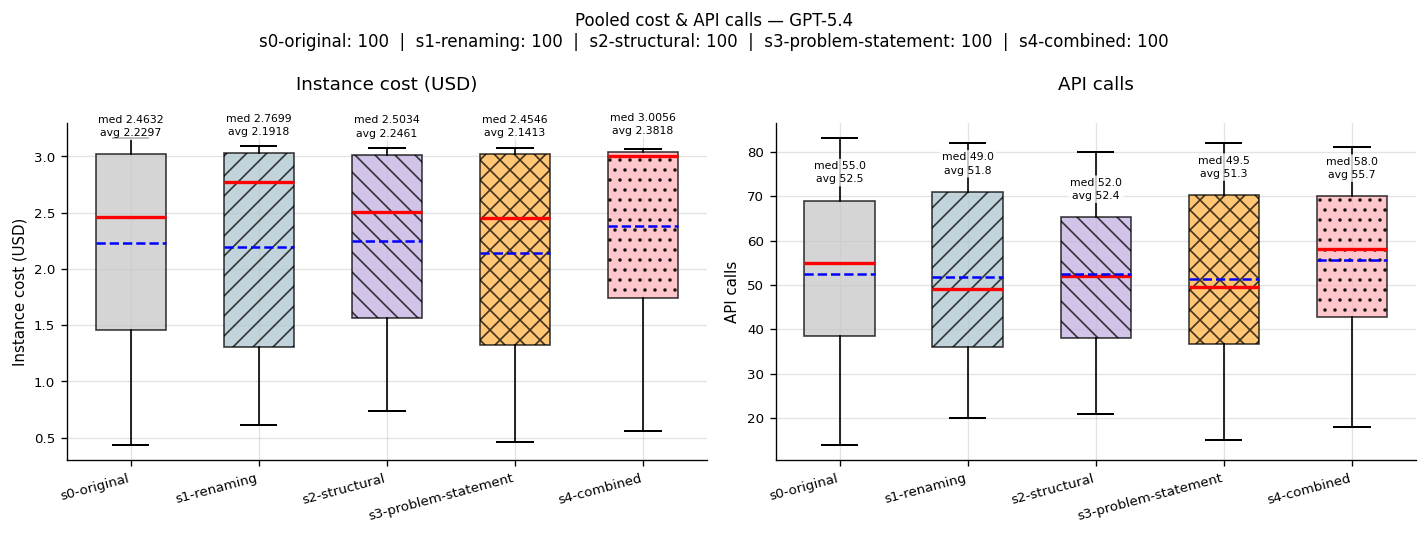

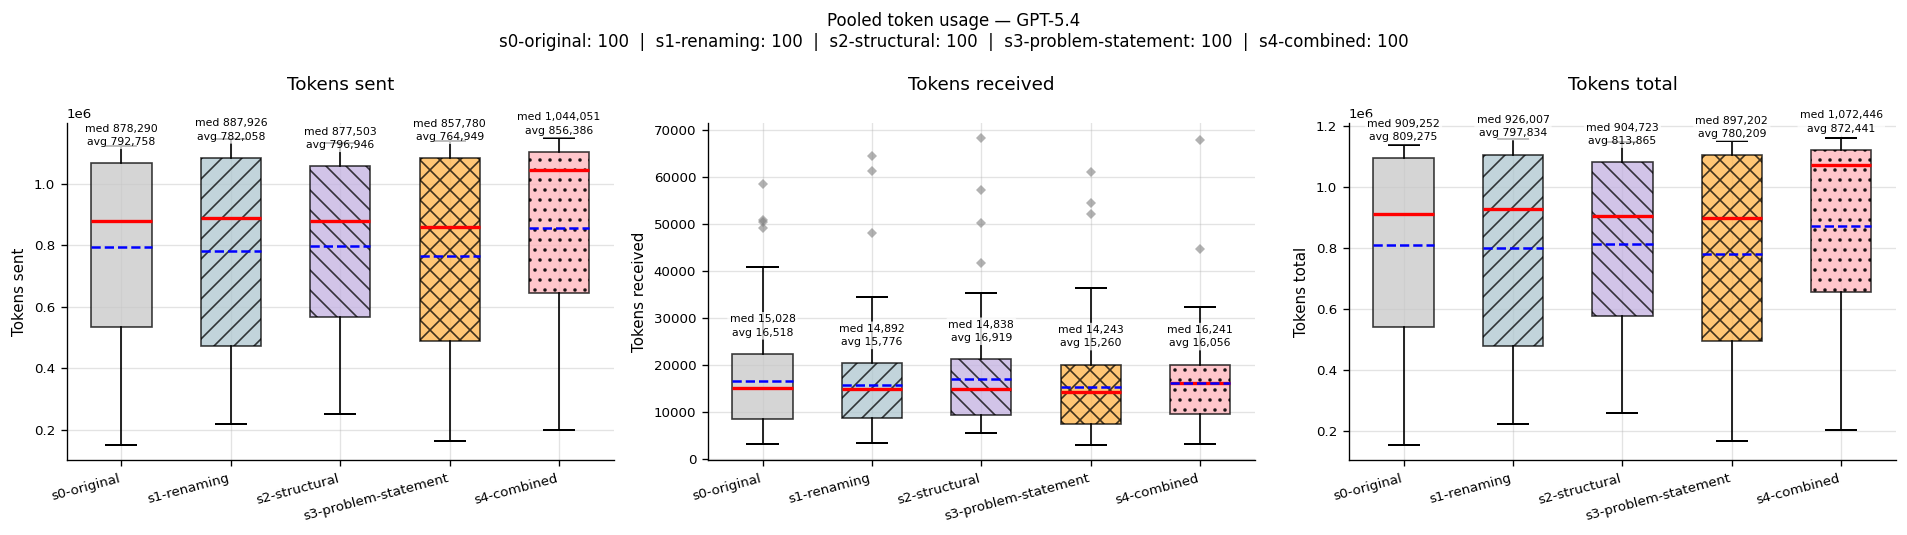

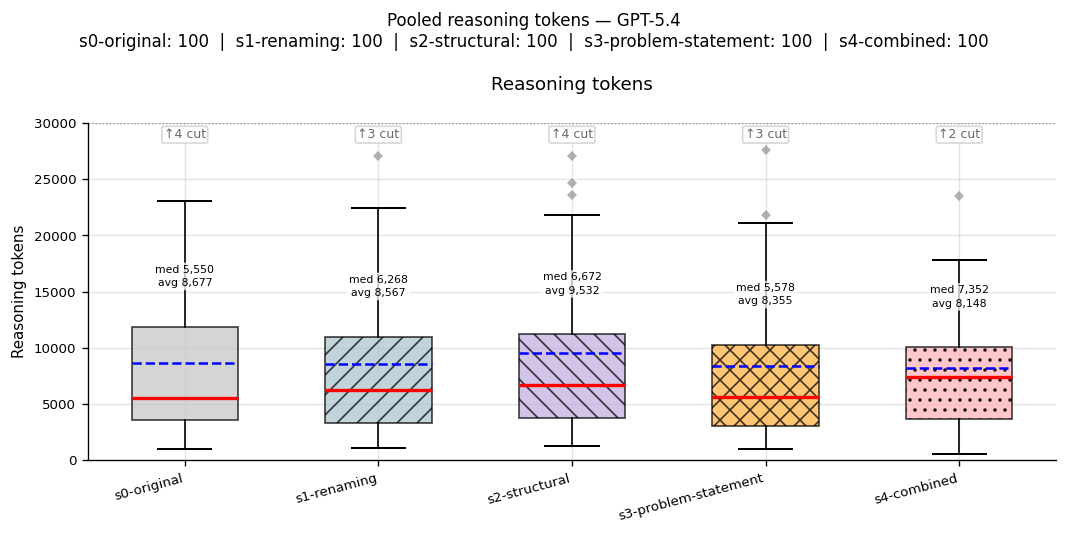

In [12]:
# ── Pooled cost, API calls & token usage ────────────────────────────────────
plot_pooled_metrics_nway(strategies, all_obs, strategies[0].model)
plt.show()

In [13]:
# ── Instance resolution table ───────────────────────────────────────────────
# Rows = instance_ids sorted by s0-original resolved count (desc).
# Cells show which runs resolved each instance (e.g. "R1, R3") or "—".
# Last row = total distinct instances resolved per strategy.
df_resolved = build_resolution_table(strategies)

from IPython.display import display
display(df_resolved)

,instance_id,s0-original,s1-renaming,s2-structural,s3-problem-statement,s4-combined
0,elastic__logstash-14970,"R2, R3, R4, R5",—,"R1, R2, R3, R4, R5","R1, R2, R3, R4, R5",—
1,elastic__logstash-14981,"R1, R3, R4, R5",—,"R1, R2, R3, R4, R5","R1, R2, R3, R4, R5",—
2,fasterxml__jackson-databind-1923,"R2, R3, R5",R5,—,—,—
3,google__gson-1093,"R2, R3",—,—,"R1, R3",—
4,elastic__logstash-16681,R2,"R1, R3, R4","R2, R4, R5",R1,"R1, R2, R3, R4, R5"
5,fasterxml__jackson-core-183,R3,—,—,R2,R3
6,mockito__mockito-3129,R4,"R1, R2, R3, R4","R1, R3","R2, R3, R4, R5","R3, R4, R5"
7,alibaba__fastjson2-82,—,—,—,—,—
8,apache__dubbo-11781,—,—,—,—,—
9,elastic__logstash-13914,—,—,—,—,—


In [14]:
# ── Statistical significance: s0-original vs each other strategy ────────────
# Wilcoxon rank-sum test (α=0.05). Highlighted cells = significant (p<0.05).
# pass_rate: per-run values (N = n_runs); agent metrics: pooled obs (N = runs × instances).
# A12 > 0.5 → s0-original tends to produce larger values.
s0 = next(s for s in strategies if s.name == "s0-original")
comparisons = [
    (s.display_name, all_metrics[s.name], all_obs[s.name])
    for s in strategies if s.name != "s0-original"
]
labels_sX = [c[0] for c in comparisons]

df_sig = build_compact_stat_sig_df(all_metrics[s0.name], all_obs[s0.name], comparisons)
display_compact_stat_sig(df_sig, s0.display_name, labels_sX)

,med(s0-original),med(s1-renaming),p(s1-renaming),A12(s1-renaming),med(s2-structural),p(s2-structural),A12(s2-structural),med(s3-problem-statement),p(s3-problem-statement),A12(s3-problem-statement),med(s4-combined),p(s4-combined),A12(s4-combined)
metric,,,,,,,,,,,,,
pass_rate,15.8%,10.0,0.115,—,15.0,0.290,—,20.0,0.747,—,10.0,0.141,—
instance_cost,$2.4632,$2.7699,0.693,—,$2.5034,0.946,—,$2.4546,0.656,—,$3.0056,0.080,—
api_calls,55.0,49.0,0.833,—,52.0,0.894,—,49.5,0.696,—,58.0,0.207,—
tokens_sent,"878,290","887,926",0.754,—,"877,503",0.964,—,"857,780",0.763,—,"1,044,051",0.017*,0.40 (small)
tokens_received,"15,028","14,892",0.694,—,"14,838",0.622,—,"14,243",0.349,—,"16,241",0.776,—
tokens_total,"909,252","926,007",0.711,—,"904,723",0.941,—,"897,202",0.744,—,"1,072,446",0.016*,0.40 (small)


In [15]:
# ── Per-instance pass rates (resolved / total runs per strategy) ─────────────
# Shows "X/N" fractions for each instance × strategy.
# Sorted by s0-original resolved count descending — same order as resolution table.
df_pr = build_per_instance_pass_rate_nway(strategies, all_pass_rates_by_id)
display(df_pr)

,instance_id,s0-original,s1-renaming,s2-structural,s3-problem-statement,s4-combined
0,elastic__logstash-14970,4/5,0/5,5/5,5/5,0/5
1,elastic__logstash-14981,4/5,0/5,5/5,5/5,0/5
2,fasterxml__jackson-databind-1923,3/5,1/5,0/5,0/5,0/5
3,google__gson-1093,2/5,0/5,0/5,2/5,0/5
4,elastic__logstash-16681,1/5,3/5,3/5,1/5,5/5
5,fasterxml__jackson-core-183,1/5,0/5,0/5,1/5,1/5
6,mockito__mockito-3129,1/5,4/5,2/5,4/5,3/5
7,alibaba__fastjson2-82,0/5,0/5,0/5,0/5,0/5
8,apache__dubbo-11781,0/5,0/5,0/5,0/5,0/5
9,elastic__logstash-13914,0/5,0/5,0/5,0/5,0/5


In [16]:
# ── Per-instance statistical significance (pooled obs, s0 vs each strategy) ──
# One table per metric field. Rows sorted by number of significant comparisons
# (descending) so the most interesting instances appear first.
# Yellow + * = significant (p < 0.05). A12 > 0.5 → s0 tends to be larger.
display_per_instance_metric_sig_nway(strategies, all_obs_by_id)

,med(s0-original),med(s1-renaming),p(s1-renaming),A12(s1-renaming),med(s2-structural),p(s2-structural),A12(s2-structural),med(s3-problem-statement),p(s3-problem-statement),A12(s3-problem-statement),med(s4-combined),p(s4-combined),A12(s4-combined)
instance_id,,,,,,,,,,,,,
fasterxml__jackson-databind-2036,$2.3283,$2.8769,0.222,—,$3.0058,0.056,—,$2.4488,0.690,—,$3.0299,0.016*,0.04 (large)
mockito__mockito-3129,$3.0464,$3.0281,0.841,—,$2.7362,0.056,—,$3.0361,0.841,—,$3.0366,0.421,—
elastic__logstash-16681,$3.0461,$3.0465,0.690,—,$3.0434,0.421,—,$3.0340,0.151,—,$3.0167,0.095,—
elastic__logstash-16579,$3.0303,$3.0353,0.421,—,$3.0124,0.690,—,$3.0428,0.222,—,$3.0094,1.000,—
mockito__mockito-3173,$3.0266,$3.0238,0.421,—,$3.0238,1.000,—,$3.0157,0.548,—,$3.0330,1.000,—
mockito__mockito-3167,$3.0161,$3.0376,0.222,—,$3.0092,1.000,—,$3.0159,1.000,—,$3.0085,0.841,—
elastic__logstash-13914,$3.0138,$3.0442,0.222,—,$3.0240,0.421,—,$3.0498,0.151,—,$3.0338,0.056,—
alibaba__fastjson2-82,$3.0132,$3.0244,0.548,—,$2.2520,0.310,—,$3.0113,0.548,—,$3.0192,1.000,—
mockito__mockito-3424,$3.0085,$3.0272,0.421,—,$3.0158,0.841,—,$3.0281,0.841,—,$3.0391,0.690,—


,med(s0-original),med(s1-renaming),p(s1-renaming),A12(s1-renaming),med(s2-structural),p(s2-structural),A12(s2-structural),med(s3-problem-statement),p(s3-problem-statement),A12(s3-problem-statement),med(s4-combined),p(s4-combined),A12(s4-combined)
instance_id,,,,,,,,,,,,,
fasterxml__jackson-databind-2036,60.0,62.0,0.249,—,64.0,0.116,—,58.0,1.000,—,69.0,0.027*,0.06 (large)
elastic__logstash-13914,78.0,77.0,1.000,—,73.0,0.463,—,76.0,0.841,—,74.0,0.690,—
mockito__mockito-3173,76.0,72.0,0.080,—,76.0,0.456,—,74.0,0.287,—,76.0,0.502,—
mockito__mockito-3424,76.0,76.0,0.589,—,74.0,0.401,—,69.0,0.530,—,79.0,0.402,—
alibaba__fastjson2-82,70.0,62.0,0.209,—,64.0,0.248,—,70.0,0.832,—,66.0,0.526,—
mockito__mockito-3167,70.0,72.0,0.138,—,66.0,0.753,—,73.0,0.141,—,77.0,0.402,—
mockito__mockito-3129,69.0,70.0,0.832,—,66.0,0.462,—,73.0,0.056,—,68.0,0.834,—
fasterxml__jackson-core-370,59.0,61.0,0.690,—,52.0,0.690,—,41.0,1.000,—,69.0,0.207,—
googlecontainertools__jib-4144,58.0,43.0,0.344,—,55.0,0.293,—,61.0,0.916,—,66.0,1.000,—


In [17]:
# ── Metric summary: median & avg + Δ% vs s0-original ───────────────────────
# Green Δ = metric increased vs s0; red Δ = metric decreased.
# pass_rate: per-run values; agent metrics: pooled per-instance observations.
df_summary = build_metrics_summary_df(strategies, all_metrics, all_obs)
display_metrics_summary(df_summary, strategies)

,s0_med,s0_avg,s1-renaming_med,s1-renaming_avg,s1-renaming_Δmed,s1-renaming_Δavg,s2-structural_med,s2-structural_avg,s2-structural_Δmed,s2-structural_Δavg,s3-problem-statement_med,s3-problem-statement_avg,s3-problem-statement_Δmed,s3-problem-statement_Δavg,s4-combined_med,s4-combined_avg,s4-combined_Δmed,s4-combined_Δavg
metric,,,,,,,,,,,,,,,,,,
pass_rate,15.8%,16.2%,10.0%,8.2%,-5.8% (-36.7%),-8.0% (-49.5%),15.0%,15.0%,-0.8% (-5.0%),-1.2% (-7.2%),20.0%,19.0%,+4.2% (+26.7%),+2.8% (+17.6%),10.0%,9.2%,-5.8% (-36.7%),-7.0% (-43.3%)
instance_cost,$2.4632,$2.2297,$2.7699,$2.1918,+$0.3067 (+12.5%),-$0.0379 (-1.7%),$2.5034,$2.2461,+$0.0402 (+1.6%),+$0.0165 (+0.7%),$2.4546,$2.1413,-$0.0086 (-0.4%),-$0.0884 (-4.0%),$3.0056,$2.3818,+$0.5424 (+22.0%),+$0.1521 (+6.8%)
api_calls,55.0,52.5,49.0,51.8,-6.0 (-10.9%),-0.8 (-1.4%),52.0,52.4,-3.0 (-5.5%),-0.1 (-0.2%),49.5,51.3,-5.5 (-10.0%),-1.2 (-2.3%),58.0,55.7,+3.0 (+5.5%),+3.2 (+6.0%)
tokens_sent,"878,290","792,758","887,926","782,058","+9,636 (+1.1%)","-10,700 (-1.3%)","877,503","796,946",-787 (-0.1%),"+4,188 (+0.5%)","857,780","764,949","-20,510 (-2.3%)","-27,809 (-3.5%)","1,044,051","856,386","+165,761 (+18.9%)","+63,628 (+8.0%)"
tokens_received,"15,028","16,518","14,892","15,776",-137 (-0.9%),-742 (-4.5%),"14,838","16,919",-190 (-1.3%),+401 (+2.4%),"14,243","15,260",-786 (-5.2%),"-1,257 (-7.6%)","16,241","16,056","+1,212 (+8.1%)",-462 (-2.8%)
tokens_total,"909,252","809,275","926,007","797,834","+16,756 (+1.8%)","-11,442 (-1.4%)","904,723","813,865","-4,528 (-0.5%)","+4,589 (+0.6%)","897,202","780,209","-12,050 (-1.3%)","-29,066 (-3.6%)","1,072,446","872,441","+163,195 (+17.9%)","+63,166 (+7.8%)"
